# Lab 1: Wstęp do DICOM

## Czym jest DICOM?
DICOM (Digital Imaging and Communications in Medicine) to standard przechowywania i wymiany obrazów medycznych.
Nie jest to zwykły format graficzny (jak JPEG czy PNG). Plik `.dcm` to zaawansowany kontener, który zawiera:
1. **Nagłówek (Metadane):** Tagi z informacjami o pacjencie, badaniu i parametrach fizycznych (np. wielkość piksela).
2. **Macierz pikseli (Pixel Data):** Surowe wartości zarejestrowanego sygnału (np. gęstość radiologiczna w jednostkach Hounsfielda dla TK).

Na tych zajęciach nauczymy się wczytywać takie pliki, odczytywać z nich dane i poprawnie rysować obrazy medyczne w skali szarości.

In [4]:
# Importujemy niezbędne biblioteki
import pydicom # Główna biblioteka do obsługi DICOM w Pythonie
import matplotlib.pyplot as plt # Do rysowania wykresów i wyświetlania obrazów
import numpy as np # Do zaawansowanych operacji na macierzach

# Ustawienie domyślnej wielkości wykresów, aby były czytelne
plt.rcParams['figure.figsize'] = (8, 8)

## 1. Wczytanie pliku DICOM
Użyjemy wbudowanego pliku testowego (obraz Tomografii Komputerowej) z biblioteki `pydicom`. W prawdziwych zastosowaniach w to miejsce wstawicie ścieżkę do własnego pliku (np. `dane/badanie1.dcm`).

In [9]:
# Pobranie ścieżki do przykładowego pliku DICOM z biblioteki
from pydicom.data import get_testdata_files
filename = get_testdata_files("CT_small.dcm")[0]

print(f"Będziemy pracować na pliku: {filename}")

# WCZYTANIE PLIKU DO ZMIENNEJ:
ds = pydicom.dcmread(filename)

# Możemy wyświetlić całą zawartość nagłówka
# Odkomentuj poniższą linijkę, aby zobaczyć wszystkie tagi DICOM:
print(ds)

Będziemy pracować na pliku: C:\Users\krzys\AppData\Roaming\Python\Python312\site-packages\pydicom\data\test_files\CT_small.dcm
Dataset.file_meta -------------------------------
(0002,0000) File Meta Information Group Length  UL: 192
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: CT Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 1.3.6.1.4.1.5962.1.1.1.1.1.20040119072730.12322
(0002,0010) Transfer Syntax UID                 UI: Explicit VR Little Endian
(0002,0012) Implementation Class UID            UI: 1.3.6.1.4.1.5962.2
(0002,0013) Implementation Version Name         SH: 'DCTOOL100'
(0002,0016) Source Application Entity Title     AE: 'CLUNIE1'
-------------------------------------------------
(0008,0005) Specific Character Set              CS: 'ISO_IR 100'
(0008,0008) Image Type                          CS: ['ORIGINAL', 'PRIMARY', 'AXIAL']
(0008,0012) Instance Creation Date              DA: '200401

## 2. Dostęp do tagów (Metadanych)
Każda informacja w nagłówku DICOM zapisana jest pod konkretnym tagiem. Do poszczególnych elementów możemy odwoływać się tak, jak do atrybutów obiektu w Pythonie (po nazwie tagu).

In [12]:
print("--- INFORMACJE O BADANIU ---")
print(f"ID Pacjenta: {ds.PatientID}")
print(f"Modalność (Urządzenie): {ds.Modality}")
print(f"Data badania: {ds.StudyDate}")

print("\n--- PARAMETRY FIZYCZNE ---")
# Uwaga: Dla niektórych tagów (np. grubość warstwy), które mogą nie występować 
# w każdym pliku, bezpieczniej użyć metody .get()
print(f"Grubość warstwy (Slice Thickness): {ds.get('SliceThickness', 'Brak tagu')} mm")
print(f"Rozmiar piksela (Pixel Spacing): {ds.get('PixelSpacing', 'Brak tagu')} mm")
print(f"Rozmiar macierzy obrazu: {ds.Rows} x {ds.Columns} pikseli")

--- INFORMACJE O BADANIU ---
ID Pacjenta: 1CT1
Modalność (Urządzenie): CT
Data badania: 20040119

--- PARAMETRY FIZYCZNE ---
Grubość warstwy (Slice Thickness): 5.000000 mm
Rozmiar piksela (Pixel Spacing): [0.661468, 0.661468] mm
Rozmiar macierzy obrazu: 128 x 128 pikseli


## 3. Praca z obrazem (Pixel Data)
Aby dostać się do właściwego "obrazu" zapisanego w pliku, używamy atrybutu `.pixel_array`. Automatycznie dekoduje on wartości do postaci macierzy biblioteki `numpy`, która jest podstawowym standardem do obliczeń numerycznych w Pythonie.

In [15]:
# Pobranie macierzy pikseli
image_matrix = ds.pixel_array

print(f"Typ obiektu: {type(image_matrix)}")
print(f"Kształt macierzy (wymiary): {image_matrix.shape}")
print(f"Typ danych pikseli (dtype): {image_matrix.dtype}") # Zazwyczaj int16, czyli liczby całkowite ze znakiem
print(f"Maksymalna wartość sygnału w pliku: {np.max(image_matrix)}")
print(f"Minimalna wartość sygnału w pliku: {np.min(image_matrix)}")

Typ obiektu: <class 'numpy.ndarray'>
Kształt macierzy (wymiary): (128, 128)
Typ danych pikseli (dtype): int16
Maksymalna wartość sygnału w pliku: 2191
Minimalna wartość sygnału w pliku: 128


## 4. Wizualizacja obrazu medycznego
Do wyświetlenia obrazu użyjemy funkcji `imshow` z biblioteki `matplotlib`. 
**Ważna uwaga:** Domyślna mapa kolorów w matplotlib nałoży na obraz sztuczne (często bardzo jaskrawe) barwy. Obrazy radiologiczne zawsze należy wymusić na odcienie szarości przy pomocy argumentu `cmap='gray'`.

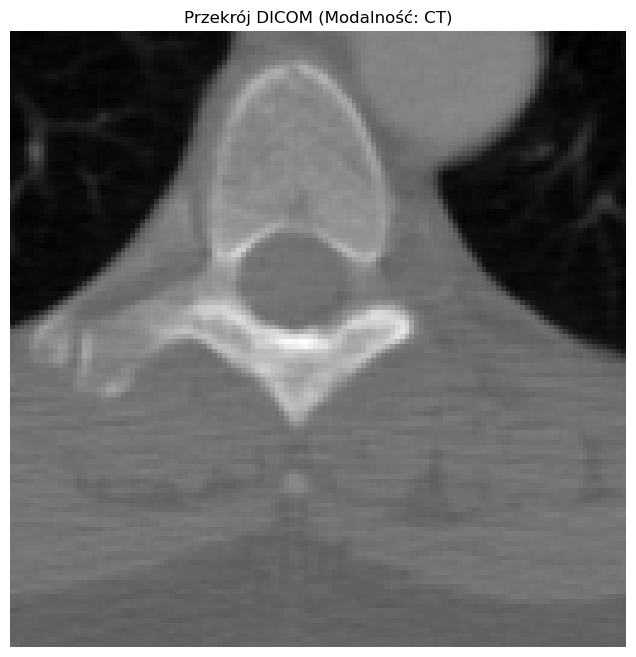

In [18]:
# Rysujemy obraz
plt.imshow(image_matrix, cmap='gray')

# Dodajemy detale ułatwiające czytanie
plt.title(f"Przekrój DICOM (Modalność: {ds.Modality})")
plt.axis('off') # Ukrywa osie X i Y (często zbędne przy oglądaniu narządów)

# Wyświetlamy efekt końcowy na ekranie
plt.show()

## 5. Zadanie samodzielne
W poniższej komórce spróbuj pobrać i wydrukować do konsoli parametry takie jak:
1. Nazwa Producenta sprzętu (Tag: `Manufacturer`)
2. Napięcie lampy rentgenowskiej użyte przy badaniu (Tag: `KVP`)

In [44]:
# Miejsce na Twój kod:
# ...
